![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier


In [7]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [9]:
# Celda 1.1
season_mean = bikes.groupby('season')['total'].mean().reset_index()
season_mean['percentage'] = (season_mean['total'] / season_mean['total'].sum()) * 100
season_mean

,season,total,percentage
0,1,116.343261,15.208268
1,2,215.251372,28.137432
2,3,234.417124,30.642759
3,4,198.988296,26.011540


In [10]:
# Celda 1.2
hora_promedio = bikes.groupby('hour').total.mean()
hora_promedio

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [11]:
# Cantidad de tiempo con menor y mayor rentas promedio
max_hora = hora_promedio.idxmax()
max_total = hora_promedio.max()

min_hora = hora_promedio.idxmin()
min_total = hora_promedio.min()

# Promedio general
Promedio_general = hora_promedio.mean()

print(f"Hora con más rentas: {max_hora} ({max_total:.2f} rentas)")
print(f"Hora con menos rentas: {min_hora} ({min_total:.2f} rentas)")
print(f"Promedio de rentas por hora: {Promedio_general:.2f}")


Hora con más rentas: 17 (468.77 rentas)
Hora con menos rentas: 4 (6.41 rentas)
Promedio de rentas por hora: 190.74


### Análisis descriptivo
Teniendo presente los análsis anteriores podemos evidenciar que:
- En promedio el 31% de las bicicletas se rentan en verano (3).
- El 28% se renta en primavera (2).
- El 26% en otoño (4)
- La temporada en la que menos se rentan bicicletas es en invierno, con un porcentaje de 15% de las rentas totales durante el periodo evaluado.
- La distribución de estos porcentajes tiene sentido considerando que los días soleados y sin lluvias motivan facilitan el uso de este tipo de transporte.
- Las bicicletas tienen un periodo de renta entre 0 y 23 horas.
- La mayoría de las rentas tienen un periodo de 17 horas, por lo que probablemente las personas usan las bicicletas rentadas para movilizarse desde sus casas a sus lugares de trabajo o estudio.
- Por otro lado, el tiempo de renta que menos se repite es de 4 horas.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

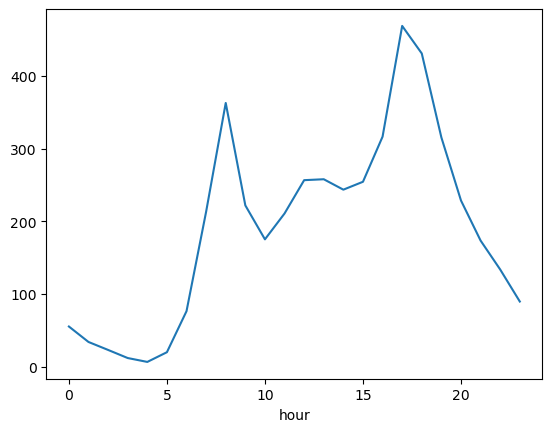

In [14]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: title={'center': 'Rentas por hora Invierno'}, xlabel='hour'>

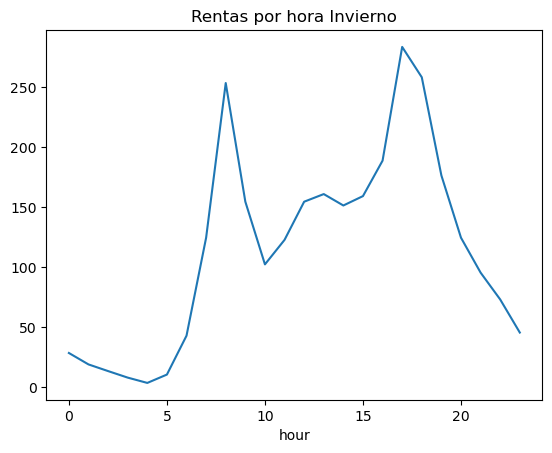

In [15]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes.loc[bikes['season'] == 1].groupby('hour')['total'].mean().plot(title="Rentas por hora Invierno")

<Axes: title={'center': 'Rentas por hora Verano'}, xlabel='hour'>

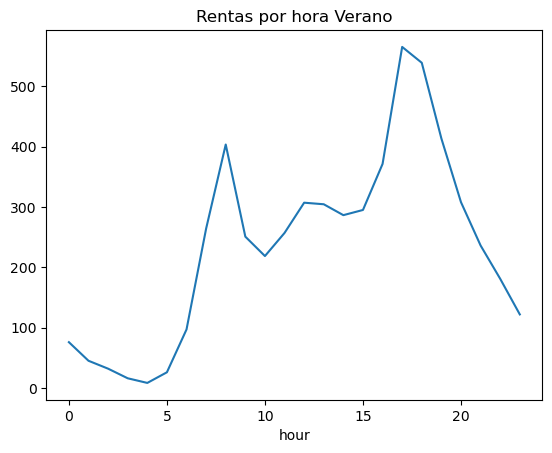

In [16]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes.loc[bikes['season'] == 3].groupby('hour')['total'].mean().plot(title="Rentas por hora Verano")

### Análisis de gráficas
Al analizar el comportamiento de las rentas promedio para cada valor de la variable "hour" para todo el periodo de tiempo analizado y posteriormente para las estaciones de invierno y verano podemos identificar que:
- En todos los casos la curva tiene un comportamiento similar con picos altos en 8 y 17 horas, y un valor mínimo en 4 horas.
- El valor del eje "y" en todos los casos nos muestra la diferencia entre la cantidad de rentas en el verano y el invierno, mostrándonos al mismo tiempo que la cantidad de rentas en el verano están por encima del promedio; mientras la cantidad de rentas en el invierno se encuentran por debajo del promedio.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a todo el conjunto de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [19]:
# Celda 3
X = bikes[['hour','season']]
y = bikes['total']

#Dividimos la muestra en un set de prueba y otro de entrenamiento
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.3, random_state=0)

#Entrenamos el modelo de regresión
model = LinearRegression()
model.fit(XTrain, yTrain)

#Predecimos las obersavaciones en el set de prueba
Pred_LR = model.predict(XTest)

#Imprimimos los coeficientes del modelo
coeficientes = dict(zip(X.columns, model.coef_))
print("Coeficientes:", coeficientes)

Coeficientes: {'hour': 10.556160175384127, 'season': 27.577533437052978}


### Análisis
Teniendo en cuenta los coeficientes del modelo y las premisas del mismo considerando la naturaleza de los datos podemos concluir que:
- Por cada hora adicional el número de bicicletas aumenta en 10.56 unidades
- Un incremento en la variable "season" aumenta en 27.58 unidades el número de bicicletas rentadas.
- Teniendo presente que la variable "season" es categórica con cuatro clases (invierno, primavera, verano y otoño) y que el modelo la interpreta como una variable contínua, es erróneo interpretar que un aumento en esta variable representa un cambio lineal en la cantidad de rentas.
- Teniendo presente que el comportamiento del número de rentas no es lineal respecto a la cantidad de horas, un modelo de regresión lineal no sería adecuado para estimar la cantidad de rentas.
- Este tipo de modelos no considera la interacción entre variable, por lo que se estaría dejando de lado el cambio en las horas rentadas respecto a la estación del año.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

### Definición de funciones iniciales 

In [23]:
#MSE para medir el rendimiento de los modelos
def mse(y):
    return np.mean((y - y.mean())**2)


#MSE Impurity: Calcular la reducción de error
def mse_impurity(X_col, y, split):
    filter_l = X_col < split
    y_l, y_r = y.loc[filter_l], y.loc[~filter_l]
    
    n_l, n_r = y_l.shape[0], y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    mse_impurity_ = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return mse_impurity_

# Best Split: Calcular la mejor variable y punto de corte para hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [None, None, float('-inf')]  
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

### Función Principal

In [25]:
# Tree Grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level, min_gain, max_depth, num_pct):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() 

    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree



### Visualización de resultados

In [27]:
#Identificamos cuántos niveles y cuántos nodos tiene el árbol
def count_leaves(tree):
    if "sl" not in tree and "sr" not in tree:
        return 1
    return count_leaves(tree["sl"]) + count_leaves(tree["sr"])

def count_levels(tree):
    if "sl" not in tree and "sr" not in tree:
        return 1
    return 1 + max(count_levels(tree["sl"]), count_levels(tree["sr"]))

#Visualización de resultados
tree = tree_grow(X, y, level=0, min_gain=0.0001, max_depth=4, num_pct=10)
print("Número de nodos finales:", count_leaves(tree))
print("Profundidad del árbol:", count_levels(tree))
tree

Número de nodos finales: 15
Profundidad del árbol: 5


{'y_pred': 191.57413191254824,
 'level': 0,
 'split': [0, 8.0],
 'n_samples': 10886,
 'gain': 9134.40591176651,
 'sl': {'y_pred': 55.437673900946024,
  'level': 1,
  'split': [0, 7.0],
  'n_samples': 3594,
  'gain': 3603.8503299798276,
  'sl': {'y_pred': 32.58203249442498,
   'level': 2,
   'split': [0, 6.0],
   'n_samples': 3139,
   'gain': 323.4004463794779,
   'sl': {'y_pred': 25.177719821162444,
    'level': 3,
    'split': [0, 2.0],
    'n_samples': 2684,
    'gain': 191.40441543023144,
    'sl': {'y_pred': 44.51045104510451,
     'level': 4,
     'split': -1,
     'n_samples': 909,
     'gain': 145.70023409125633},
    'sr': {'y_pred': 15.27718309859155,
     'level': 4,
     'split': -1,
     'n_samples': 1775,
     'gain': 19.614949636834638}},
   'sr': {'y_pred': 76.25934065934067,
    'level': 3,
    'split': [1, 2.0],
    'n_samples': 455,
    'gain': 371.54779616750875,
    'sl': {'y_pred': 42.72566371681416,
     'level': 4,
     'split': -1,
     'n_samples': 113,
     'g

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

In [29]:
# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 21)

# Lista para guardar los valores del RMSE para cada valor de máxima profundidad
rmse_scores = []

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    # Definición del árbol de decisión
    reg = DecisionTreeRegressor(max_depth=depth, random_state=1)

    # Entrenamos el modelo con el set de entrenamiento
    reg.fit(XTrain, yTrain)

    # Evaluamos el modelo con set de prueba
    y_pred = reg.predict(XTest)

    # Calculamos el RMSE en los datos de prueba y lo guardamos en la lista creada al inicio
    rmse = np.sqrt(mean_squared_error(yTest, y_pred))
    rmse_scores.append(rmse)

# Al finalizar el ciclo identificamos la mejor profundidad (mínimo RMSE)
best_depth, best_rmse = sorted(zip(max_depth_range, rmse_scores), key=lambda x: x[1])[0]

print(f"Mejor max_depth: {best_depth} con RMSE: {best_rmse:.4f}")

Mejor max_depth: 8 con RMSE: 115.2192


In [30]:
# Calculamos el MSE
mse_LR = mean_squared_error(yTest, Pred_LR)

# Calculamos el RMSE
rmse_LR = np.sqrt(mse_LR)

# Imprimimos el resultado
print(f"RMSE: {rmse:.4f}")

RMSE: 115.3209


### Interpretación de resultados
Los resultados de este modelo nos indican que el árbol con mejor desempeño tienen una profundidad de 8 niveles y un RMSE de 115.2192.
Al comparar el resultado del RMSE de los dos modelos (Regresión Lineal y Árbol de Decisiones) se observa que ambos modelos tienen un desempeño muy similar y ningún modelo estaría teniendo una ventaja predictiva sobre el otro.
El error en los dos casos es muy alto lo que indica que ambos modelos tienen dificultades para predecir la variable objetivo con las dos variables incluidas, lo que podría indicar la necesidad de incluir variables adicionales.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [34]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [35]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [36]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

### Árbol de Decisión

In [39]:
#Estimamos el modelo en la muestra de entrenamiento
clfTree = DecisionTreeClassifier(max_depth=6, min_samples_split=15, min_samples_leaf=5)
clfTree.fit(X_train, y_train)

#Predicción del modelo en la muestra de prueba
prediccionTree = clfTree.predict(X_test)

#Cálculo de Accuracy
print('Accuracy')
accuracyRegLog=round(accuracy_score(y_true=y_test, y_pred=prediccionTree),5)
print(accuracyRegLog)

# Cálculo de F1-Score
f1 = f1_score(y_test, prediccionTree)
print(f'F1-Score: {f1:.4f}')

Accuracy
0.62533
F1-Score: 0.6228


### Regresión Logística

In [41]:
#Estimamos el modelo en la muestra de entrenamiento
clfRegLog= LogisticRegression(random_state=0,max_iter=10000)
clfRegLog.fit(X_train,y_train)

#Predicción del modelo en la muestra de prueba
prediccionesRegLog=clfRegLog.predict(X_test)

#Cálculo de Accuracy
print('Accuracy')
accuracyRegLog=round(accuracy_score(y_true=y_test, y_pred=prediccionesRegLog),5)
print(accuracyRegLog)

# Cálculo de F1-Score
f1 = f1_score(y_test, prediccionesRegLog)
print(f'F1-Score: {f1:.4f}')

Accuracy
0.61933
F1-Score: 0.6021


### Interpretación de resultados
Teniendo presente los resultados obtenidos se puede concluir que:
- En el árbol de decisión se ajustaron los siguientes parámetros max_depth, min_samples_split y min_samples_leaf; y esto generó un mejor desempeño del modelo.
- El accuracy obetnido en los dos casos se encuentra por el orden de 62%
- Por su parte el F1-Score se encuentra entre 60% y 62% siendo el del modelo de regresión logística el mejor.
- Teniendo presente las métricas evaluadas los dos modelos presentan un desempeño similar, siendo el del árbol de decisión levemente mejor que el de regresión logística.


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [44]:
# Celda 7
#Definimos el número de modelos de cada tipo
n_estimators_per_type = 100
total_estimators = 3 * n_estimators_per_type

#Fijamos la semilla
np.random.seed(123)

#Creamos las muestras de boostrap
n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(total_estimators)]

#Creamos semillas aleatorias para cada modelo
seeds = np.random.randint(1, 10000, size=total_estimators)

#Creamos un diccionario que almacenará los modelos
models = {}

### Primeras 100 muestras (Árboles de decisión calibrando Profundidad)

In [46]:
max_depth_value = 5
for i in range(n_estimators_per_type):
    models[i] = DecisionTreeClassifier(max_depth=max_depth_value, random_state=seeds[i])
    models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

### Segundas 100 muestras (Árboles de decisión calibrando Cantidad Mínima de Hojas)

In [48]:
min_samples_leaf_value = 10
for i in range(n_estimators_per_type, 2 * n_estimators_per_type):
    models[i] = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf_value, random_state=seeds[i])
    models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

### Últimas 100 muestras (Regresión logística)

In [50]:
for i in range(2 * n_estimators_per_type, total_estimators):
    models[i] = LogisticRegression(max_iter=500, random_state=seeds[i])
    models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

### Predicción y evaluación de cada modelo

In [52]:
# Predicción para los datos del set de test con cada modelo
y_pred_df = pd.DataFrame(index=X_test.index, columns=list(range(total_estimators)))

for i in range(total_estimators):
    y_pred_df.iloc[:, i] = models[i].predict(X_test)

#Definción de función para evaluar modelos
def evaluar_modelos(indices, nombre_modelo):
    y_pred_individual = (y_pred_df.iloc[:, indices].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)
    accuracy = accuracy_score(y_test, y_pred_individual)
    f1 = f1_score(y_test, y_pred_individual)
    print(f"\n{nombre_modelo}")
    print(f"\nAccuracy: {accuracy:.5f}")
    print(f"\nF1-Score: {f1:.5f}")
    print ()

#Evaluación de cada modelo
evaluar_modelos(range(0, n_estimators_per_type), "Primer modelo: Árboles (max_depth)")
evaluar_modelos(range(n_estimators_per_type, 2 * n_estimators_per_type), "Segundo modelo: Árboles (min_samples_leaf)")
evaluar_modelos(range(2 * n_estimators_per_type, total_estimators), "Tercer modelo: Regresión Logística")


Primer modelo: Árboles (max_depth)

Accuracy: 0.65467

F1-Score: 0.65282


Segundo modelo: Árboles (min_samples_leaf)

Accuracy: 0.65267

F1-Score: 0.65474


Tercer modelo: Regresión Logística

Accuracy: 0.61333

F1-Score: 0.59945



### Votación Mayoritaria

In [54]:
# Hacemos votación mayoritaria
y_pred_VM = (y_pred_df.sum(axis=1) >= (total_estimators / 2)).astype(int)

# Evaluar el modelo al aplicar votación mayoritaria
accuracy_VM= accuracy_score(y_test, y_pred_VM)
f1_VM = f1_score(y_test, y_pred_VM)

print("\nResultados al hacer Votación Mayoritaria")
print(f"Accuracy: {accuracy_VM:.5f}")
print(f"F1-Score: {f1_VM:.5f}")


Resultados al hacer Votación Mayoritaria
Accuracy: 0.64000
F1-Score: 0.63115


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [56]:
# Celda 8

## Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
samples_oob = []
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

In [57]:
# Estimación de los errores OOB para cada clasificador
errors = np.zeros(total_estimators)

for i in range(total_estimators):
    y_pred_oob = models[i].predict(X_train.iloc[samples_oob[i]])
    #errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_oob)
    errors[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_oob)

In [58]:
# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha = (1 - errors) / (1 - errors).sum()

In [59]:
# Ponderación de las predicciones con los pesos alpha
weighted_sum_1 = ((y_pred_df) * alpha).sum(axis=1)

# Votación Ponderada
y_pred_VP = (weighted_sum_1 >= 0.5).astype(np.int64)

# Evaluar el modelo al aplicar votación ponderada
accuracy_VP= accuracy_score(y_test, y_pred_VP)
f1_VP = f1_score(y_test, y_pred_VP)

print("\nResultados al hacer Votación Ponderada")
print(f"Accuracy: {accuracy_VP:.5f}")
print(f"F1-Score: {f1_VP:.5f}")


Resultados al hacer Votación Ponderada
Accuracy: 0.63667
F1-Score: 0.62799


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [61]:
# Celda 9
#Hacemos una tabla para visualizar los resultados
resultados = {
    "Modelo": [
        "Árboles (max_depth)",
        "Árboles (min_samples_leaf)",
        "Regresión Logística",
        "Votación Mayoritaria",
        "Votación Ponderada"
    ],
    "Accuracy": [
        accuracy_score(y_test, (y_pred_df.iloc[:, :n_estimators_per_type].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        accuracy_score(y_test, (y_pred_df.iloc[:, n_estimators_per_type:2 * n_estimators_per_type].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        accuracy_score(y_test, (y_pred_df.iloc[:, 2 * n_estimators_per_type:].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        accuracy_VM,
        accuracy_VP
    ],
    "F1-Score": [
        f1_score(y_test, (y_pred_df.iloc[:, :n_estimators_per_type].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        f1_score(y_test, (y_pred_df.iloc[:, n_estimators_per_type:2 * n_estimators_per_type].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        f1_score(y_test, (y_pred_df.iloc[:, 2 * n_estimators_per_type:].sum(axis=1) >= (n_estimators_per_type / 2)).astype(int)),
        f1_VM,
        f1_VP
    ]
}

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Accuracy,F1-Score
0,Árboles (max_depth),0.654667,0.652815
1,Árboles (min_samples_leaf),0.652667,0.654738
2,Regresión Logística,0.613333,0.599448
3,Votación Mayoritaria,0.640000,0.631148
4,Votación Ponderada,0.636667,0.627986


### Análisis de resultados
Teniendo presente los resultados obtenidos podemos concluir que:
- Los mejores resultados de las métricas evaluadas, accuracy y de F1-Score, fueron obtenidas con los modelos de árboles de decisiones al calibrar su profundidad y el número de muestras por hojas.
- La evaluación de los modelos individuales indica que la regresión logística obtiene los menores resultados, esto podría indicar que los datos no tienen una estructura, y por lo tanto los árboles de decisión logran capturar mejor la relación entre las variables independientes y la variable objetivo.
- Los modelos de ensamble evaluados, votación mayoritaria y votación ponderada, no lograron superar los resultados obtenidos con árboles de decisiones; sin embargo, se observa que el desempeño de votación mayoritaria es levemente mejor que el obtenido por votación ponderada.
- El mejor modelo individual y a nivel general resulta ser árbol de decisión calibrando el parámetro "min_samples_leaf" con 10; ya presenta el mejor puntaje F1 y su accuracy es comparable con el obtenido al calibrar árbol de decisión con una profundidad de 5.
- Teniendo presente los resultados obtenidos al evaluar los modelos de ensamblaje se identifica que considerar la regresión logística afecta negativamente los resultados del ensamble.